<a href="https://colab.research.google.com/github/FarahBelghith2/PFE/blob/main/XGBOOST2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports + configuration

In [1]:
import pandas as pd
import numpy as np
import re
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
TARGET = "reservations"

# Features robustes et générales
FEATURES = [
    "heure_num",
    "heure_sin",
    "heure_cos",
    "jour_semaine",
    "est_weekend",
    "mois",
    "saison",
    "ferie",
    "jour_ouvrable",
    "is_vacances_scolaires",
    "meteo",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "event_type",
    "event_strength",
    "site_id"
]

CATEGORICAL_COLS = [
    "jour_semaine",
    "saison",
    "meteo",
    "event_type",
    "site_id"
]

NUMERIC_COLS = [
    "heure_num",
    "heure_sin",
    "heure_cos",
    "est_weekend",
    "mois",
    "ferie",
    "jour_ouvrable",
    "is_vacances_scolaires",
    "temperature_c",
    "humidite_pct",
    "vent_kmh",
    "event_strength"
]

In [4]:
COLUMN_ALIASES = {
    "date": ["date", "dteday", "day", "booking_date"],
    "heure_num": ["heure_num", "hr", "hour", "heure"],
    "ferie": ["ferie", "holiday", "is_holiday"],
    "jour_ouvrable": ["jour_ouvrable", "workingday", "working_day"],
    "jour_semaine": ["jour_semaine", "weekday_name", "day_name", "weekday"],
    "saison": ["saison", "season"],
    "meteo": ["meteo", "weather", "weathersit"],
    "temperature_c": ["temperature_c", "temp", "temperature"],
    "humidite_pct": ["humidite_pct", "hum", "humidity"],
    "vent_kmh": ["vent_kmh", "windspeed", "wind_speed"],
    "reservations": ["reservations", "cnt", "count", "target"],
    "nom_event_local": ["nom_event_local", "event_name", "event", "nom_evenement"],
    "is_vacances_scolaires": ["is_vacances_scolaires", "is_vacation", "vacation", "school_holiday"]
}


def drop_duplicate_columns(df):
    df = df.copy()
    return df.loc[:, ~df.columns.duplicated()]


def normalize_columns(df):
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace("\ufeff", "", regex=False)
        .str.replace(" ", "_", regex=False)
    )
    return df


def rename_with_aliases(df, aliases):
    df = df.copy()

    for canonical_name, possible_names in aliases.items():
        if canonical_name in df.columns:
            cols_to_drop = [
                col for col in possible_names
                if col in df.columns and col != canonical_name
            ]
            if cols_to_drop:
                df = df.drop(columns=cols_to_drop, errors="ignore")
        else:
            for alias in possible_names:
                if alias in df.columns:
                    df = df.rename(columns={alias: canonical_name})
                    break

    return drop_duplicate_columns(df)


def parse_heure_num(x):
    x = str(x).strip().lower()

    if x in ["nan", "none", ""]:
        return np.nan

    if "h" in x:
        return pd.to_numeric(x.split("h")[0], errors="coerce")

    if ":" in x:
        return pd.to_numeric(x.split(":")[0], errors="coerce")

    return pd.to_numeric(x, errors="coerce")

In [5]:
def extract_event_type(event_name):
    txt = str(event_name).strip().lower()

    if txt in ["", "aucun", "none", "nan"]:
        return "none"

    if "champions league" in txt or "ligue des champions" in txt:
        return "champions_league"
    elif "coupe du monde" in txt:
        return "world_cup"
    elif "finale" in txt:
        return "finale"
    elif "concert" in txt:
        return "concert"
    elif "festival" in txt:
        return "festival"
    elif "match" in txt or "derby" in txt:
        return "match"
    elif "tournoi" in txt:
        return "tournoi"
    elif "coupe" in txt:
        return "coupe"
    elif "grand prix" in txt:
        return "grand_prix"
    else:
        return "other"


def extract_event_strength(event_name):
    txt = str(event_name).strip().lower()

    if txt in ["", "aucun", "none", "nan"]:
        return 0

    if "champions league" in txt or "ligue des champions" in txt:
        return 3
    elif "coupe du monde" in txt:
        return 3
    elif "finale" in txt:
        return 3
    elif "concert" in txt:
        return 2
    elif "festival" in txt:
        return 2
    elif "grand prix" in txt:
        return 2
    elif "match" in txt or "tournoi" in txt or "coupe" in txt:
        return 1
    else:
        return 1

In [6]:
def adapt_any_base(df_raw, site_id="unknown_site"):
    df = df_raw.copy()

    # 1) normaliser
    df = normalize_columns(df)

    # 2) renommer
    df = rename_with_aliases(df, COLUMN_ALIASES)

    # 3) supprimer doublons
    df = drop_duplicate_columns(df)

    # 4) colonnes obligatoires minimales
    required_cols = [
        "date", "heure_num", "ferie", "jour_ouvrable", "jour_semaine", "saison",
        "meteo", "temperature_c", "humidite_pct", "vent_kmh",
        "reservations", "nom_event_local", "is_vacances_scolaires"
    ]
    for col in required_cols:
        if col not in df.columns:
            if col in ["ferie", "jour_ouvrable", "is_vacances_scolaires"]:
                df[col] = 0
            elif col == "nom_event_local":
                df[col] = "Aucun"
            else:
                df[col] = np.nan

    # 5) date
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df = df.dropna(subset=["date"]).copy()

    # 6) heure
    df["heure_num"] = df["heure_num"].apply(parse_heure_num)
    df = df.dropna(subset=["heure_num"]).copy()
    df["heure_num"] = df["heure_num"].astype(int)

    # 7) variables temporelles
    df["annee"] = df["date"].dt.year
    df["mois"] = df["date"].dt.month
    df["jour_mois"] = df["date"].dt.day
    df["jour_semaine_num"] = df["date"].dt.weekday

    mapping_jours = {
        0: "lundi",
        1: "mardi",
        2: "mercredi",
        3: "jeudi",
        4: "vendredi",
        5: "samedi",
        6: "dimanche"
    }
    df["jour_semaine"] = df["jour_semaine_num"].map(mapping_jours)

    # 8) weekend
    df["est_weekend"] = df["jour_semaine_num"].isin([5, 6]).astype(int)

    # 9) saison
    if df["saison"].isna().all() or (df["saison"].astype(str).str.strip() == "").all():
        def month_to_season(month):
            if month in [12, 1, 2]:
                return "hiver"
            elif month in [3, 4, 5]:
                return "printemps"
            elif month in [6, 7, 8]:
                return "été"
            else:
                return "automne"
        df["saison"] = df["mois"].apply(month_to_season)

    df["saison"] = df["saison"].astype(str).str.strip().str.lower()

    # 10) météo
    df["meteo"] = df["meteo"].astype(str).str.strip().str.lower()
    mapping_meteo = {
        "ensoleille": "ensoleillé",
        "soleil": "ensoleillé",
        "clear": "ensoleillé",
        "clair": "ensoleillé",
        "rain": "pluvieux",
        "pluie": "pluvieux",
        "cloudy": "nuageux",
        "nuage": "nuageux",
        "storm": "orageux",
        "orage": "orageux"
    }
    df["meteo"] = df["meteo"].replace(mapping_meteo)

    # 11) numériques
    for col in ["ferie", "jour_ouvrable", "is_vacances_scolaires", "temperature_c", "humidite_pct", "vent_kmh", "reservations"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    # 12) heure cyclique
    df["heure_sin"] = np.sin(2 * np.pi * df["heure_num"] / 24)
    df["heure_cos"] = np.cos(2 * np.pi * df["heure_num"] / 24)

    # 13) événement robuste
    df["nom_event_local"] = df["nom_event_local"].fillna("Aucun").astype(str)
    df["event_type"] = df["nom_event_local"].apply(extract_event_type)
    df["event_strength"] = df["nom_event_local"].apply(extract_event_strength)

    # 14) site
    df["site_id"] = site_id

    return df


In [7]:
# Base A
df_A = pd.read_csv("/content/drive/MyDrive/PFE/base_finale_auto_2024_2025_clean.csv", sep=";")
df_A = adapt_any_base(df_A, site_id="site_A")

# Base B
df_B = pd.read_csv("/content/drive/MyDrive/PFE/base_test_externe.csv", sep=",")
df_B = adapt_any_base(df_B, site_id="site_B")

print("Shape A :", df_A.shape)
print("Shape B :", df_B.shape)


Shape A : (6877, 30)
Shape B : (6878, 29)


In [8]:
# =========================================================
# SPLIT PAR SITE (80% train / 20% test dans chaque base)
# =========================================================

def split_par_site(df, train_ratio=0.8):
    df = df.sort_values(["date", "heure_num"]).reset_index(drop=True)
    split_idx = int(len(df) * train_ratio)

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    return df_train, df_test

# Split séparé pour chaque base
df_A_train, df_A_test = split_par_site(df_A, train_ratio=0.8)
df_B_train, df_B_test = split_par_site(df_B, train_ratio=0.8)

# Fusionner les trains et les tests
df_train = pd.concat([df_A_train, df_B_train], ignore_index=True)
df_test = pd.concat([df_A_test, df_B_test], ignore_index=True)

print("Train par site :")
print(df_train["site_id"].value_counts())

print("\nTest par site :")
print(df_test["site_id"].value_counts())

Train par site :
site_id
site_B    5502
site_A    5501
Name: count, dtype: int64

Test par site :
site_id
site_A    1376
site_B    1376
Name: count, dtype: int64


In [9]:
# =========================================================
# X_train / X_test / y_train / y_test
# =========================================================

# Optionnel : trier encore une fois proprement
df_train = df_train.sort_values(["date", "heure_num", "site_id"]).reset_index(drop=True)
df_test = df_test.sort_values(["date", "heure_num", "site_id"]).reset_index(drop=True)

# Construire X et y
X_train = df_train[FEATURES].copy()
X_test = df_test[FEATURES].copy()

y_train = np.log1p(df_train[TARGET].copy())
y_test = np.log1p(df_test[TARGET].copy())

print("Shape X_train :", X_train.shape)
print("Shape X_test  :", X_test.shape)

Shape X_train : (11003, 17)
Shape X_test  : (2752, 17)


In [26]:
# =========================================================
# PREPROCESSOR + MODELE
# =========================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("encoder", OneHotEncoder(handle_unknown="ignore"))
            ]),
            CATEGORICAL_COLS
        ),
        (
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            NUMERIC_COLS
        )
    ]
)

model =XGBRegressor(
    objective="reg:squarederror",
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

pipeline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

pipeline_model.fit(X_train, y_train)

print("✅ Modèle robuste entraîné avec succès")

✅ Modèle robuste entraîné avec succès


In [11]:
# =========================================================
# PREDICTIONS
# =========================================================

y_pred_log = pipeline_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

y_pred = np.maximum(0, y_pred)

In [27]:
# =========================================================
# EVALUATION GLOBALE
# =========================================================

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("=== Performance globale modèle robuste ===")
print("MAE  :", round(mae, 4))
print("RMSE :", round(rmse, 4))
print("R2   :", round(r2, 4))

=== Performance globale modèle robuste ===
MAE  : 47.3375
RMSE : 92.3515
R2   : 0.7456


In [25]:
# =========================================================
# EVALUATION PAR SITE
# =========================================================

resultats_test = df_test.copy()
resultats_test["reservations_reelles"] = y_true
resultats_test["reservations_prevues"] = y_pred

print("Répartition des lignes test par site :")
print(resultats_test["site_id"].value_counts())

for site in resultats_test["site_id"].unique():
    subset = resultats_test[resultats_test["site_id"] == site]

    mae_site = mean_absolute_error(subset["reservations_reelles"], subset["reservations_prevues"])
    rmse_site = np.sqrt(mean_squared_error(subset["reservations_reelles"], subset["reservations_prevues"]))
    r2_site = r2_score(subset["reservations_reelles"], subset["reservations_prevues"])

    print(f"\n=== {site} ===")
    print("MAE  :", round(mae_site, 4))
    print("RMSE :", round(rmse_site, 4))
    print("R2   :", round(r2_site, 4))

Répartition des lignes test par site :
site_id
site_B    1376
site_A    1376
Name: count, dtype: int64

=== site_B ===
MAE  : 90.7591
RMSE : 130.4428
R2   : 0.6198

=== site_A ===
MAE  : 3.9159
RMSE : 6.501
R2   : 0.9655


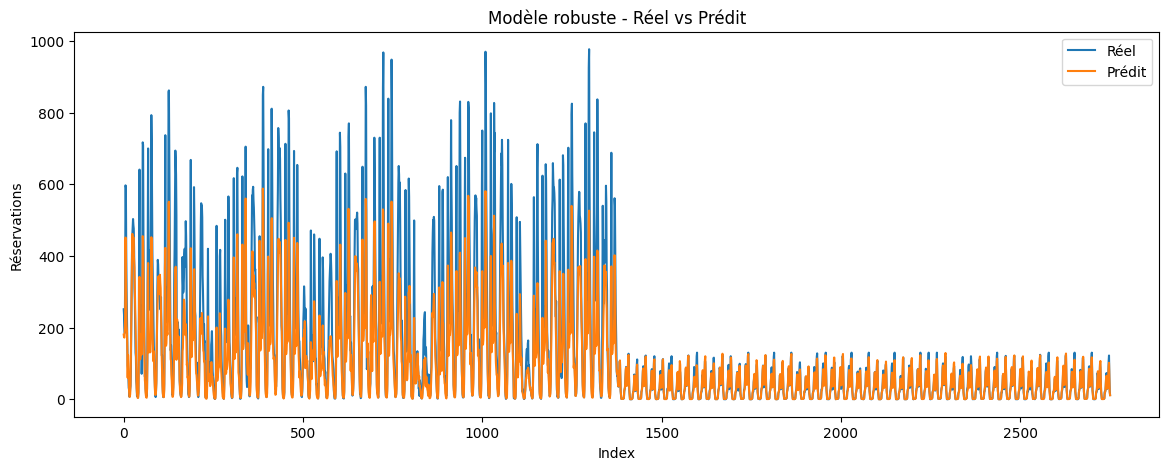

In [14]:
# =========================================================
# GRAPHIQUE REEL VS PREDIT
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(resultats_test["reservations_reelles"].reset_index(drop=True), label="Réel")
plt.plot(resultats_test["reservations_prevues"].reset_index(drop=True), label="Prédit")
plt.legend()
plt.title("Modèle robuste - Réel vs Prédit")
plt.xlabel("Index")
plt.ylabel("Réservations")
plt.show()

In [15]:
print(df_test["site_id"].value_counts())

site_id
site_B    1376
site_A    1376
Name: count, dtype: int64


In [16]:
# =========================================================
# PROMO - LOGIQUE DE L'ANCIEN MODELE ADAPTEE AU MODELE ROBUSTE
# =========================================================

CFG_PROMO = {
    "promo_max": 30,
    "plafond": 30,
    "plancher": 0
}

def calibrer_seuils(predictions):
    return {
        "bas": float(np.percentile(predictions, 20)),
        "haut": float(np.percentile(predictions, 70)),
    }

SEUILS = calibrer_seuils(y_pred)

print("Seuil bas :", round(SEUILS["bas"], 2))
print("Seuil haut :", round(SEUILS["haut"], 2))


def calcul_promo_dynamique_sans_capacite(reservations_prevues, seuils, promo_max=30):
    """
    Promo de base :
    - demande faible -> promo élevée
    - demande forte -> promo nulle
    """
    bas = seuils["bas"]
    haut = seuils["haut"]

    if reservations_prevues >= haut:
        return 0

    if reservations_prevues <= bas:
        return promo_max

    ratio = (reservations_prevues - bas) / (haut - bas)
    ratio = max(0, min(ratio, 1))

    promo = promo_max * (1 - ratio)

    if promo < 5:
        return 0

    return int(round(promo / 5) * 5)


def ajuster_promo_selon_contexte(
    promo_base,
    jour_semaine,
    heure,
    meteo,
    ferie,
    is_vacances_scolaires,
    event_type,
    event_strength,
    type_terrain
):
    """
    Logique promo inspirée de l'ancien modèle,
    mais adaptée aux variables robustes du nouveau modèle.
    """
    promo = promo_base

    jour_semaine = str(jour_semaine).lower().strip()
    meteo = str(meteo).lower().strip()
    event_type = str(event_type).lower().strip()
    type_terrain = str(type_terrain).lower().strip()

    # --------------------------------
    # 1) JOUR / HEURE
    # --------------------------------
    # lundi matin creux
    if jour_semaine == "lundi" and 9 <= heure <= 11:
        promo += 5

    # mardi à jeudi après-midi
    if jour_semaine in ["mardi", "mercredi", "jeudi"] and 14 <= heure <= 17:
        promo += 5

    # lundi à vendredi midi
    if jour_semaine in ["lundi", "mardi", "mercredi", "jeudi", "vendredi"] and 12 <= heure <= 14 and int(ferie) == 0:
        promo += 5

    # vendredi soir
    if jour_semaine == "vendredi" and 19 <= heure <= 22:
        promo -= 5

    # samedi / dimanche bons créneaux
    if jour_semaine in ["samedi", "dimanche"] and (12 <= heure <= 15 or 19 <= heure <= 21):
        promo -= 5

    # --------------------------------
    # 2) METEO SELON TYPE TERRAIN
    # --------------------------------
    if type_terrain == "outdoor":
        if meteo in ["pluvieux", "orageux", "venteux"]:
            promo += 10
        elif meteo == "nuageux":
            promo += 5
        elif meteo in ["ensoleillé", "ensoleille", "clair", "nuit_claire"]:
            promo -= 5

    elif type_terrain == "indoor":
        if meteo in ["pluvieux", "orageux"]:
            promo -= 5
        elif meteo in ["ensoleillé", "ensoleille", "clair"]:
            promo += 5

    # --------------------------------
    # 3) JOUR FERIE
    # --------------------------------
    if int(ferie) == 1:
        # ancien modèle : si férié, créneau potentiellement attractif
        promo -= 5

        meteo_mauvaise = ["pluvieux", "nuageux", "venteux", "orageux"]
        if meteo in meteo_mauvaise:
            promo += 5

    # --------------------------------
    # 4) VACANCES
    # --------------------------------
    if int(is_vacances_scolaires) == 1:
        promo -= 5

    # --------------------------------
    # 5) EVENEMENT
    # --------------------------------
    # ancien modèle : gros évènement -> moins de promo
    if event_type != "none":
        if int(event_strength) >= 3:
            promo -= 10
        elif int(event_strength) == 2:
            promo -= 5
        else:
            promo -= 5

    # bornes
    promo = max(CFG_PROMO["plancher"], min(promo, CFG_PROMO["plafond"]))

    if promo < 5:
        return 0

    return int(round(promo / 5) * 5)


def recommander_promo_finale(
    reservations_prevues,
    seuils,
    jour_semaine,
    heure,
    meteo,
    ferie,
    is_vacances_scolaires,
    event_type,
    event_strength,
    type_terrain
):
    promo_base = calcul_promo_dynamique_sans_capacite(
        reservations_prevues,
        seuils,
        promo_max=CFG_PROMO["promo_max"]
    )

    if promo_base == 0:
        return 0

    return ajuster_promo_selon_contexte(
        promo_base,
        jour_semaine,
        heure,
        meteo,
        ferie,
        is_vacances_scolaires,
        event_type,
        event_strength,
        type_terrain
    )


Seuil bas : 5.94
Seuil haut : 110.35


In [17]:
# =========================================================
# PREPARER LE TABLEAU DE RESULTATS TEST
# =========================================================

resultats_modele = df_test.copy()

# Valeurs réelles / prédites
resultats_modele["reservations_reelles"] = y_true
resultats_modele["reservations_prevues"] = np.round(y_pred, 2)

# sécurité colonnes utiles pour promo
if "type_terrain" not in resultats_modele.columns:
    resultats_modele["type_terrain"] = "outdoor"

if "event_type" not in resultats_modele.columns:
    resultats_modele["event_type"] = "none"

if "event_strength" not in resultats_modele.columns:
    resultats_modele["event_strength"] = 0

if "nom_jour_ferie" not in resultats_modele.columns:
    resultats_modele["nom_jour_ferie"] = "Aucun"

if "zone_scolaire" not in resultats_modele.columns:
    resultats_modele["zone_scolaire"] = "C"

# affichage jour / heure
def format_heure(h):
    return f"{int(h):02d}h00"

resultats_modele["heure_affichage"] = resultats_modele["heure_num"].apply(format_heure)
resultats_modele["jour_nom"] = resultats_modele["jour_semaine"]

print(resultats_modele[[
    "date", "site_id", "jour_nom", "heure_affichage",
    "reservations_reelles", "reservations_prevues"
]].head(10))

        date site_id  jour_nom heure_affichage  reservations_reelles  \
0 2012-08-03  site_B  vendredi           12h00                 251.0   
1 2012-08-03  site_B  vendredi           13h00                 233.0   
2 2012-08-03  site_B  vendredi           14h00                 203.0   
3 2012-08-03  site_B  vendredi           15h00                 185.0   
4 2012-08-03  site_B  vendredi           16h00                 342.0   
5 2012-08-03  site_B  vendredi           17h00                 597.0   
6 2012-08-03  site_B  vendredi           18h00                 590.0   
7 2012-08-03  site_B  vendredi           19h00                 416.0   
8 2012-08-03  site_B  vendredi           20h00                 302.0   
9 2012-08-03  site_B  vendredi           21h00                 233.0   

   reservations_prevues  
0            180.399994  
1            172.710007  
2            172.119995  
3            189.110001  
4            232.559998  
5            451.390015  
6            363.690002  

In [30]:
# =========================================================
# GENERATION DES PROMOS - UNIQUEMENT POUR LA BASE A
# =========================================================

# Filtrer uniquement site_A
resultats_site_A = resultats_modele[resultats_modele["site_id"] == "site_A"].copy()

promo_finale = [
    recommander_promo_finale(
        reservations_prevues=row["reservations_prevues"],
        seuils=SEUILS,
        jour_semaine=row["jour_semaine"],
        heure=row["heure_num"],
        meteo=row["meteo"],
        ferie=row["ferie"],
        is_vacances_scolaires=row["is_vacances_scolaires"],
        event_type=row["event_type"],
        event_strength=row["event_strength"],
        type_terrain=row["type_terrain"]
    )
    for _, row in resultats_site_A.iterrows()
]

resultats_site_A["promo_finale"] = promo_finale
resultats_site_A["promo_affichage"] = resultats_site_A["promo_finale"].astype(int).astype(str) + "%"

print("\n✅ Aperçu résultats + promo - Base A (2024-2025) :")
print(resultats_site_A[[
    "date",
    "site_id",
    "jour_nom",
    "heure_affichage",
    "type_terrain",
    "meteo",
    "ferie",
    "is_vacances_scolaires",
    "event_type",
    "event_strength",
    "reservations_reelles",
    "reservations_prevues",
    "promo_affichage"
]].head(30).to_string(index=False))


✅ Aperçu résultats + promo - Base A (2024-2025) :
      date site_id jour_nom heure_affichage type_terrain      meteo  ferie  is_vacances_scolaires event_type  event_strength  reservations_reelles  reservations_prevues promo_affichage
2025-08-03  site_A dimanche           12h00      outdoor    nuageux      0                      0    concert               2                  65.0             70.959999              5%
2025-08-03  site_A dimanche           13h00      outdoor    nuageux      0                      0    concert               2                  75.0             79.500000              5%
2025-08-03  site_A dimanche           14h00      outdoor    nuageux      0                      0    concert               2                  51.0             53.660000             10%
2025-08-03  site_A dimanche           15h00      outdoor ensoleillé      0                      0    concert               2                  37.0             36.689999              5%
2025-08-03  site_A diman

In [31]:
# =========================================================
# NETTOYER LE TABLEAU FINAL
# =========================================================

# 1) nom_jour_ferie
resultats_modele["nom_jour_ferie"] = resultats_modele["nom_jour_ferie"].fillna("Aucun")

# 2) météo lisible
mapping_meteo_num = {
    1: "ensoleillé",
    2: "nuageux",
    3: "pluvieux",
    4: "orageux"
}
resultats_modele["meteo"] = resultats_modele["meteo"].replace(mapping_meteo_num)

# 3) supprimer colonnes inutiles
cols_to_drop = ["instant", "yr", "mnth", "atemp", "casual", "registered", "nom_event_local"]
resultats_modele = resultats_modele.drop(columns=[c for c in cols_to_drop if c in resultats_modele.columns], errors="ignore")

# 4) garder seulement les colonnes utiles
colonnes_finales = [
    "date",
    "site_id",
    "jour_nom",
    "heure_affichage",
    "type_terrain",
    "meteo",
    "ferie",
    "nom_jour_ferie",
    "is_vacances_scolaires",
    "event_type",
    "event_strength",
    "reservations_reelles",
    "reservations_prevues",
    "promo_finale",
    "promo_affichage"
]

resultats_modele_propre = resultats_modele[colonnes_finales].copy()

print(resultats_modele_propre.head(30).to_string(index=False))

      date site_id jour_nom heure_affichage type_terrain meteo  ferie nom_jour_ferie  is_vacances_scolaires event_type  event_strength  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-03  site_B vendredi           12h00      outdoor     2      0          Aucun                      0       none               0                 251.0            180.399994             0              0%
2012-08-03  site_B vendredi           13h00      outdoor     2      0          Aucun                      0       none               0                 233.0            172.710007             0              0%
2012-08-03  site_B vendredi           14h00      outdoor     2      0          Aucun                      0       none               0                 203.0            172.119995             0              0%
2012-08-03  site_B vendredi           15h00      outdoor     1      0          Aucun                      0       none               0                 185.0        

In [20]:
colonnes_finales = [
    "date",
    "site_id",
    "jour_nom",
    "heure_affichage",
    "type_terrain",
    "meteo",
    "ferie",
    "nom_jour_ferie",
    "is_vacances_scolaires",
    "event_type",
    "event_strength",
    "reservations_reelles",
    "reservations_prevues",
    "promo_finale",
    "promo_affichage"
]

resultats_modele_final = resultats_modele[colonnes_finales].copy()

print(resultats_modele_final.head(10).to_string(index=False))

      date site_id jour_nom heure_affichage type_terrain meteo  ferie nom_jour_ferie  is_vacances_scolaires event_type  event_strength  reservations_reelles  reservations_prevues  promo_finale promo_affichage
2012-08-03  site_B vendredi           12h00      outdoor     2      0          Aucun                      0       none               0                 251.0            180.399994             0              0%
2012-08-03  site_B vendredi           13h00      outdoor     2      0          Aucun                      0       none               0                 233.0            172.710007             0              0%
2012-08-03  site_B vendredi           14h00      outdoor     2      0          Aucun                      0       none               0                 203.0            172.119995             0              0%
2012-08-03  site_B vendredi           15h00      outdoor     1      0          Aucun                      0       none               0                 185.0        

In [21]:
resultats_site_B = resultats_modele[resultats_modele["site_id"] == "site_B"].copy()

print(resultats_site_B.head(10).to_string(index=False))

      date jour_semaine saison  jour_ouvrable meteo  temperature_c  humidite_pct  vent_kmh  reservations  heure_num  annee  mois  jour_mois  jour_semaine_num  weekend  semaine_annee  trimestre saison_auto  ferie nom_jour_ferie  is_vacances_scolaires zone_scolaire  is_event_local     heure_sin     heure_cos  est_weekend event_type  event_strength site_id  reservations_reelles  reservations_prevues type_terrain heure_affichage jour_nom  promo_finale promo_affichage
2012-08-03     vendredi      1              1     2           0.56          0.60    0.4478           251         12   2012     8          3                 4      NaN            NaN        NaN         NaN      0          Aucun                      0           NaN             NaN  1.224647e-16 -1.000000e+00            0       none               0  site_B                 251.0            180.399994      outdoor           12h00 vendredi             0              0%
2012-08-03     vendredi      1              1     2           0.

In [22]:
resultats_site_A = resultats_modele[resultats_modele["site_id"] == "site_A"].copy()

print(resultats_site_A.head(10).to_string(index=False))

      date jour_semaine    saison  jour_ouvrable      meteo  temperature_c  humidite_pct  vent_kmh  reservations  heure_num  annee  mois  jour_mois  jour_semaine_num  weekend  semaine_annee  trimestre saison_auto  ferie nom_jour_ferie  is_vacances_scolaires zone_scolaire  is_event_local     heure_sin     heure_cos  est_weekend event_type  event_strength site_id  reservations_reelles  reservations_prevues type_terrain heure_affichage jour_nom  promo_finale promo_affichage
2025-08-03     dimanche printemps              0    nuageux           25.7          68.0      26.9            65         12   2025     8          3                 6      1.0           10.0        1.0   printemps      0          Aucun                      0             C             1.0  1.224647e-16 -1.000000e+00            1    concert               2  site_A                  65.0             70.959999      outdoor           12h00 dimanche             5              5%
2025-08-03     dimanche printemps              0